In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import cv2
import os
import matplotlib.pyplot as plt
import torch.optim as optim
from darts_dataset import SyntheticDataset, RealWorldDataset
from darts_model import CNNTransformer, DomainDiscriminator, loss_corners, loss_darts, loss_labels, match
from score import get_score, fields

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [21]:
BATCH_SIZE=64
BATCH_SIZE_UNLABELED=16
DATA_DIRECTORY = "./3D"
LABELS_FILENAME = "imgs_std25_kind2_0/labels.pkl"
LABELS_FILEPATH =f"{DATA_DIRECTORY}/{LABELS_FILENAME}"

In [5]:
# deepdarts_dataset = pd.read_pickle("labels/labels.pkl")
# df = pd.concat([deepdarts_dataset[["img_folder", "img_name", "xy"]], pd.read_pickle(LABELS_FILEPATH)], ignore_index=True)
# df.to_pickle("./3D/labels_combined.pkl")

In [22]:
df=pd.read_pickle(LABELS_FILEPATH)
# df = df[:-7]
# df[df["img_folder"] == "C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0002"] = df[df["img_folder"] == "C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0002"][7:]
# df = df.dropna(subset=['img_folder'])
print(len(df))
df.head()

194


,img_folder,img_name,xy
0,imgs_std25_kind2_0,img_0000.png,"[[0.4420551657676697, 0.21058118343353271], [0..."
1,imgs_std25_kind2_0,img_0001.png,"[[0.4554998278617859, 0.21401453018188477], [0..."
2,imgs_std25_kind2_0,img_0002.png,"[[0.45949187874794006, 0.2481406331062317], [0..."
3,imgs_std25_kind2_0,img_0003.png,"[[0.4582001566886902, 0.22006642818450928], [0..."
4,imgs_std25_kind2_0,img_0004.png,"[[0.45390382409095764, 0.22700649499893188], [..."


In [7]:
# df.to_pickle("./3D/labels.pkl")

In [23]:
transform = transforms.Compose([
    transforms.ToTensor(),          # Convert to tensor (scales pixel values to [0,1])
    transforms.Resize(224),  # ResNet-50 expects 224x224 images
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225])   # ImageNet std
])

In [24]:
_transform = transforms.Compose([
    transforms.ToTensor(),          # Convert to tensor (scales pixel values to [0,1])
    transforms.Resize(350),  # ResNet-50 expects 224x224 images
    transforms.CenterCrop(350),
])

In [25]:
dataset = SyntheticDataset("./3D", LABELS_FILEPATH, transform=transform)
_dataset = SyntheticDataset("./3D", LABELS_FILEPATH, transform=_transform)
target_dataset = RealWorldDataset("./my_unlabelled/vids", "./my_unlabelled/vids/image_data.csv", transform=transform)
dataloader = DataLoader(dataset, collate_fn=SyntheticDataset.collate_fn, batch_size=BATCH_SIZE, shuffle=True, num_workers=1, persistent_workers=True, drop_last=True)
target_dataloader = DataLoader(target_dataset, batch_size=BATCH_SIZE_UNLABELED, shuffle=True, num_workers=1, persistent_workers=True, drop_last=True)

           img_folder      img_name  \
0  imgs_std25_kind2_0  img_0000.png   
1  imgs_std25_kind2_0  img_0001.png   
2  imgs_std25_kind2_0  img_0002.png   
3  imgs_std25_kind2_0  img_0003.png   
4  imgs_std25_kind2_0  img_0004.png   

                                                  xy  
0  [[0.4420551657676697, 0.21058118343353271], [0...  
1  [[0.4554998278617859, 0.21401453018188477], [0...  
2  [[0.45949187874794006, 0.2481406331062317], [0...  
3  [[0.4582001566886902, 0.22006642818450928], [0...  
4  [[0.45390382409095764, 0.22700649499893188], [...  
           img_folder      img_name  \
0  imgs_std25_kind2_0  img_0000.png   
1  imgs_std25_kind2_0  img_0001.png   
2  imgs_std25_kind2_0  img_0002.png   
3  imgs_std25_kind2_0  img_0003.png   
4  imgs_std25_kind2_0  img_0004.png   

                                                  xy  
0  [[0.4420551657676697, 0.21058118343353271], [0...  
1  [[0.4554998278617859, 0.21401453018188477], [0...  
2  [[0.45949187874794006, 0.2481406

(array([ 0, 20]), array([62, 38], dtype=int32))


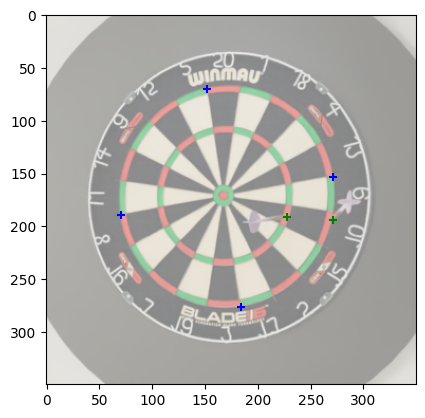

In [39]:
idx = np.random.randint(len(dataset))
image, target = _dataset[idx]
_, w, h = image.shape
print(get_score(target["corners"], target["darts"]))
fig, ax = plt.subplots(1)
ax.imshow(image.cpu().permute(1,2,0), alpha=0.5)
ax.scatter(target["corners"][:, 0]*w, target["corners"][:, 1]*h, color='blue', s=40, marker='+', label="corners")
ax.scatter(target["darts"][:, 0]*w, target["darts"][:, 1]*h, color='green', s=40, marker='+', label="darts")

In [12]:
query_dim = 256
model = CNNTransformer(d=query_dim).to(device)
discriminator = DomainDiscriminator(query_dim, 256, 2).to(device)

C:\Users\Tim\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Tim\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
param_dicts = [
    {"params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad]},
    {
        "params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad],
        "lr": 1e-5,
    },
    {
        "params": [p for p in discriminator.parameters() if p.requires_grad],
    }
]

In [14]:
# model.transformer.apply(initialize_weights)
optimizer = optim.AdamW(param_dicts, lr=1e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 200)

In [15]:
model.load_state_dict(torch.load("models/epoch_80_0.0818_0.1957_5.4597_0.7460.pt", weights_only=True), strict=True)

<All keys matched successfully>

In [16]:
START_EPOCH=80
NUM_EPOCHS=300

In [17]:
model.train()  # Set model to training mode
mse_loss = nn.MSELoss()

for epoch in range(START_EPOCH, NUM_EPOCHS):
    total_loss = 0
    total_corner_loss = 0
    total_darts_loss = 0
    total_label_loss = 0
    total_domain_acc = 0
    
    source_iter, target_iter = iter(dataloader), iter(target_dataloader)
    num_batches = min(len(source_iter), len(target_iter))
    for batch in range(num_batches):
        images, targets = next(source_iter)
        target_images = next(target_iter).to(device)
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        all_images = torch.cat((images, target_images))
        bs, channels, w, h = images.shape
        optimizer.zero_grad()          
        outputs = model(all_images)
        
        domain_input = torch.cat((outputs["extracted_features"][:BATCH_SIZE_UNLABELED], outputs["extracted_features"][BATCH_SIZE:]))
        assert domain_input.shape[0] == 2*BATCH_SIZE_UNLABELED
        domain_labels = torch.cat((
            torch.zeros(BATCH_SIZE_UNLABELED, dtype=torch.long, device=device),
            torch.ones(BATCH_SIZE_UNLABELED, dtype=torch.long, device=device)
        ))
        pred_domain = discriminator(domain_input)
        l_domain = nn.functional.cross_entropy(pred_domain, domain_labels)
        
        #remove unlabeled data
        outputs["corners"] = outputs["corners"][:, :BATCH_SIZE]
        outputs["darts"] = outputs["darts"][:, :BATCH_SIZE]
        outputs["logits"] = outputs["logits"][:, :BATCH_SIZE]
        
        l_corners, l_darts, l_labels = 0,0,0
        for decoder_layer in range(outputs["corners"].shape[0]):
            indices = match(outputs, targets, decoder_layer)
            l_corners += loss_corners(outputs, targets, decoder_layer)
            l_darts += loss_darts(outputs, targets, indices, decoder_layer)
            l_labels += loss_labels(outputs, targets, indices, decoder_layer)
        loss = 5*l_corners + 5*l_darts + 2*l_labels + 1*l_domain
        
        loss.backward()                # Backpropagation
        optimizer.step()               # Update weights
        total_loss += loss.item()
        total_corner_loss += l_corners.item()
        total_darts_loss += l_darts.item()
        total_label_loss += l_labels.item()
        total_domain_acc += torch.mean((pred_domain.argmax(dim=-1) == domain_labels).float()).item()
        if (batch+1) % 20 == 0:
            print(l_corners.item(), l_darts.item(), l_labels.item(), l_domain.item())
    lr_scheduler.step()
    if (epoch+1) % 10 == 0:
        print("saving model...")
        torch.save(model.state_dict(), f"models/epoch_{epoch+1}_{total_corner_loss/num_batches:.4f}_{total_darts_loss/num_batches:.4f}_{total_label_loss/num_batches:.4f}_{total_domain_acc/num_batches:.4f}.pt")
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Losses: {total_corner_loss/num_batches:.4f}, {total_darts_loss/num_batches:.4f}, {total_label_loss/num_batches:.4f}, {total_domain_acc/num_batches:.4f}", )

0.08230119198560715 0.1777685582637787 4.746675491333008 0.5539563298225403
Epoch [81/300], Losses: 0.0888, 0.1858, 5.4454, 0.6250
0.06308439373970032 0.17976687848567963 5.47791862487793 0.6764737367630005
Epoch [82/300], Losses: 0.0817, 0.1780, 5.0093, 0.7056
0.08173582702875137 0.1910579800605774 4.813315391540527 0.8076767325401306
Epoch [83/300], Losses: 0.0832, 0.1786, 4.8996, 0.7359
0.08062072843313217 0.163682222366333 5.138171672821045 0.3173210918903351
Epoch [84/300], Losses: 0.0862, 0.1814, 4.9450, 0.7550
0.08454117923974991 0.17948269844055176 4.760583877563477 0.6964178085327148
Epoch [85/300], Losses: 0.0795, 0.1777, 4.7691, 0.7107
0.06352649629116058 0.15673650801181793 4.4724202156066895 0.5955851674079895
Epoch [86/300], Losses: 0.0765, 0.1728, 4.5680, 0.7460
0.05677129328250885 0.16272960603237152 4.174970626831055 0.33540645241737366
Epoch [87/300], Losses: 0.0761, 0.1742, 4.5531, 0.7540
0.09211034327745438 0.17482702434062958 4.62553596496582 0.5658045411109924
Epo

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


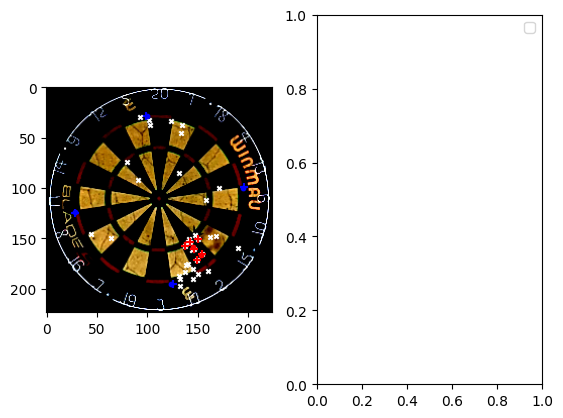

In [18]:
model.eval()
idx = np.random.randint(len(dataset))
image, targets = dataset[idx]
images = image.unsqueeze(0).to(device)
targets = [targets]
batch_size, channels, w, h = images.shape
optimizer.zero_grad()          
outputs = model(images)
pred_classes = torch.argmax(outputs["logits"][-1, 0], dim=-1)
print()
fig, ax = plt.subplots(1, 2)
ax[0].imshow(images[0].cpu().permute(1,2,0))
# ax[1].imshow(outputs["extracted_features"][-1, 0].mean(dim=0).cpu().detach())


pred_corners = outputs["corners"][-1, 0].cpu().detach()
pred_darts = outputs["darts"][-1, 0][pred_classes!=len(fields)].cpu().detach()
all_darts = outputs["darts"][-1, 0].cpu().detach()

# Draw points
ax[0].scatter(pred_corners[:, 0]*w, pred_corners[:, 1]*h, color='blue', s=40, marker='+', label="pred corners")
ax[0].scatter(all_darts[:, 0]*w, all_darts[:, 1]*h, color='white', s=10, marker='x', label="all darts")
ax[0].scatter(pred_darts[:, 0]*w, pred_darts[:, 1]*h, color='red', s=40, marker='+', label="pred darts")
ax[0].scatter(targets[0]["corners"][:, 0]*w, targets[0]["corners"][:, 1]*h, color='blue', s=10, marker='o', label="gt corners")
ax[0].scatter(targets[0]["darts"][:, 0]*w, targets[0]["darts"][:, 1]*h, color='red', s=10, marker='o', label="gt darts")

# Show plot
plt.legend()
plt.show()